Scan through multiple equilibria and find ne pedestal

In [1]:
import sys
import os
import gc
import resource
from pathlib import Path

# Put repo root on path so `src` is importable (parent of this notebook's parent).
ROOT = Path.cwd().parent.parent
sys.path.insert(0, str(ROOT))

from src.solver import saarelma_connor
import numpy as np
import matplotlib.pyplot as plt


In [2]:
# Discover all g/p file pairs in the PT_Hmode inputs folder.
inputs_dir = ROOT / 'src' / 'inputs' / 'PT_Hmode'

g_files = sorted(inputs_dir.glob('g*'))
p_files = sorted(inputs_dir.glob('p*'))

# Match g and p files by their shared suffix (everything after the leading 'g'/'p').
g_by_suffix = {f.name[1:]: f for f in g_files}
p_by_suffix = {f.name[1:]: f for f in p_files}
shared_suffixes = sorted(set(g_by_suffix) & set(p_by_suffix))

equilibria = [(str(g_by_suffix[s]), str(p_by_suffix[s])) for s in shared_suffixes]

print(f"Found {len(equilibria)} g/p file pairs in {inputs_dir}:")
for mhd_fp, kprof_fp in equilibria:
    print(f"  g: {mhd_fp}\n  p: {kprof_fp}")

Found 10 g/p file pairs in /Users/nelsonlab/codes/saarelma-conner-ped/src/inputs/PT_Hmode:
  g: /Users/nelsonlab/codes/saarelma-conner-ped/src/inputs/PT_Hmode/g150840.03000
  p: /Users/nelsonlab/codes/saarelma-conner-ped/src/inputs/PT_Hmode/p150840.03000
  g: /Users/nelsonlab/codes/saarelma-conner-ped/src/inputs/PT_Hmode/g152960.03500
  p: /Users/nelsonlab/codes/saarelma-conner-ped/src/inputs/PT_Hmode/p152960.03500
  g: /Users/nelsonlab/codes/saarelma-conner-ped/src/inputs/PT_Hmode/g153100.03000
  p: /Users/nelsonlab/codes/saarelma-conner-ped/src/inputs/PT_Hmode/p153100.03000
  g: /Users/nelsonlab/codes/saarelma-conner-ped/src/inputs/PT_Hmode/g153140.04750
  p: /Users/nelsonlab/codes/saarelma-conner-ped/src/inputs/PT_Hmode/p153140.04750
  g: /Users/nelsonlab/codes/saarelma-conner-ped/src/inputs/PT_Hmode/g153303.03100
  p: /Users/nelsonlab/codes/saarelma-conner-ped/src/inputs/PT_Hmode/p153303.03100
  g: /Users/nelsonlab/codes/saarelma-conner-ped/src/inputs/PT_Hmode/g153440.01725
  p: /U

In [3]:
# Scan size 
N = 3

# Scan parameters
alpha_crits = np.logspace(-2, 1.5, N)
C_KBMs = np.logspace(-1, 1.5, N)
De_chie_etgs = np.logspace(-1, 1.5, N)
nFC_x0s = np.logspace(14.5, 16.5, N)

# Inner-boundary threshold (used to compute the OUTER limit of the
# psi_N_inner_boundary scan range; smaller -> outer limit further inward).
# inner_thresholds = np.logspace(-6, -1, 3)
outer_threshold = 1e-6   # tightest -> outer-most position
# Number of points to sample between (slope-zero inner limit) and (outer limit).
n_psi_inner_pts = N
# Safety margin for the inner limit: place the deepest valid boundary at
# psi_N where dne/dx = safety_margin * min(dne/dx) rather than exactly 0.
# psi_inner_safety_margin = 0.01

# Static parameters
P_tot_e = 5e6  # W
solve_res = 100
verbose = False

# Output directories / files
scan_success_dir = Path('scan_success')
scan_success_dir.mkdir(parents=True, exist_ok=True)

success_fp = 'success_multi_equilibria.txt'
failure_fp = 'failure_multi_equilibria.txt'
error_messages_fp = 'error_messages_multi_equilibria.txt'

In [5]:
with open(success_fp, 'w') as f:
    f.write("equilibrium, alpha_crit, C_KBM, De_chie_etg, nFC_x0, psi_N_inner\n")
with open(failure_fp, 'w') as f:
    f.write("equilibrium, alpha_crit, C_KBM, De_chie_etg, nFC_x0, psi_N_inner\n")
with open(error_messages_fp, 'w') as f:
    f.write("equilibrium, alpha_crit, C_KBM, De_chie_etg, nFC_x0, psi_N_inner, message\n")

# Lightweight RAM reporter (no external deps)
def _ram_mb():
    rss = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss
    # macOS returns bytes; Linux returns kB
    return rss / (1024 ** 2) if sys.platform == 'darwin' else rss / 1024

# Run scan: outer loop over equilibria (g/p pairs). Within each equilibrium we
# build ONE base_model and reuse it across all parameter combinations via
# update_free_params (cheap), instead of constructing a new model per combo.
# For each parameter combo we recompute the valid range of psi_N_inner_boundary
# from the slope-zero inner limit to the nFC/nCX-threshold outer limit, then
# sample n_psi_inner_pts boundaries within that range.
n_iter = 0
for eq_idx, (mhd_fp, kprof_fp) in enumerate(equilibria):
    eq_tag = Path(mhd_fp).name[1:]  # e.g. "150840.03000"
    eq_dir = scan_success_dir / eq_tag
    eq_dir.mkdir(parents=True, exist_ok=True)

    # Clear any prior runs for this equilibrium so re-running this cell yields
    # a clean dataset.
    for old in eq_dir.glob('ne_*.npy'):
        os.remove(old)

    print(f"\n=== Equilibrium {eq_idx + 1}/{len(equilibria)}: {eq_tag} ===")

    # Build the base model ONCE per equilibrium — the expensive flux-surface
    # averaging and equilibrium loading runs here only, not inside the loop.
    base_model = saarelma_connor(
        P_tot_e       = P_tot_e,
        alpha_crit    = round(float(alpha_crits[0]), 3),
        C_KBM         = round(float(C_KBMs[0]), 3),
        De_chie_etg   = round(float(De_chie_etgs[0]), 3),
        nFC_x0        = round(float(nFC_x0s[0]), 3),
        mhd_fp        = mhd_fp,
        kprof_fp      = kprof_fp,
        verbose       = verbose,
        nFC_threshold = outer_threshold,
        nCX_threshold = outer_threshold,
    )
    print(f"  Base model built for {eq_tag} — starting scan.")

    i = 0
    for alpha_crit in alpha_crits:
        j = 0
        for C_KBM in C_KBMs:
            k = 0
            for De_chie_etg in De_chie_etgs:
                l = 0
                for nFC_x0 in nFC_x0s:
                    ac = round(float(alpha_crit), 3)
                    ck = round(float(C_KBM), 3)
                    de = round(float(De_chie_etg), 3)
                    nf = round(float(nFC_x0), 3)

                    # Step 1: apply free params with adaptive thresholds active
                    # so inner_boundary_limits can compute the outer limit.
                    base_model.update_free_params(
                        alpha_crit    = ac,
                        C_KBM         = ck,
                        De_chie_etg   = de,
                        nFC_x0        = nf,
                        nFC_threshold = outer_threshold,
                        nCX_threshold = outer_threshold,
                    )
                    try:
                        psi_inner_lim, psi_outer_lim = base_model.inner_boundary_limits(
                            outer_threshold = outer_threshold,
                            x_res           = solve_res,
                        )
                    except Exception as e:
                        with open(error_messages_fp, 'a') as f:
                            f.write(f"{eq_tag}, {ac}, {ck}, {de}, {nf}, range_failed, {e}\n")
                        continue

                    if psi_inner_lim >= psi_outer_lim:
                        psi_scan = np.array([psi_outer_lim])
                    else:
                        psi_scan = np.linspace(psi_inner_lim, psi_outer_lim, n_psi_inner_pts)

                    for psi_b in psi_scan:
                        psi_val = round(float(psi_b), 4)
                        try:
                            base_model.update_free_params(
                                alpha_crit           = ac,
                                C_KBM                = ck,
                                De_chie_etg          = de,
                                nFC_x0               = nf,
                                psi_N_inner_boundary = psi_val,
                            )
                            base_model.solve(x_res=solve_res)
                        except Exception as e:  # run fails
                            with open(failure_fp, 'a') as f:
                                f.write(f"{eq_tag}, {ac}, {ck}, {de}, {nf}, {psi_val:.4f}\n")
                            with open(error_messages_fp, 'a') as f:
                                f.write(f"{eq_tag}, {ac}, {ck}, {de}, {nf}, {psi_val:.4f}, {e}\n")
                        else:  # run works
                            with open(success_fp, 'a') as f:
                                f.write(f"{eq_tag}, {ac}, {ck}, {de}, {nf}, {psi_val:.4f}\n")
                            np.save(
                                eq_dir / f"ne_a{ac}_C{ck}_D{de}_n{nf}_b{psi_val:.4f}",
                                base_model.sol,
                                allow_pickle=True,
                            )
                        n_iter += 1
                        if n_iter % 25 == 0:
                            gc.collect()
                            print(f"    [{n_iter} iters] peak RAM ~ {_ram_mb():.0f} MB")
                    l += 1
                k += 1
                print(f"  Completed {k} of {len(De_chie_etgs)} De_chie_etgs")
            j += 1
            print(f"  Completed {j} of {len(C_KBMs)} C_KBMs")
        i += 1
        print(f"Completed {i} of {len(alpha_crits)} alpha_crits for equilibrium {eq_tag}")

    # Drop the per-equilibrium base model before moving to the next one.
    del base_model
    gc.collect()


=== Equilibrium 1/10: 150840.03000 ===
  Base model built for 150840.03000 — starting scan.
psi_N_inner_boundary: 0.8906
x_inner: -0.0400 m
No valid inner boundary found, defaulting to psi_N=0.85 for inner boundary
psi_N_inner_boundary: 0.8906
x_inner: -0.0400 m
No valid inner boundary found, defaulting to psi_N=0.85 for inner boundary
psi_N_inner_boundary: 0.8906
x_inner: -0.0400 m
No valid inner boundary found, defaulting to psi_N=0.85 for inner boundary
  Completed 1 of 3 De_chie_etgs
psi_N_inner_boundary: 0.8906
x_inner: -0.0400 m
No valid inner boundary found, defaulting to psi_N=0.85 for inner boundary
psi_N_inner_boundary: 0.8906
x_inner: -0.0400 m
No valid inner boundary found, defaulting to psi_N=0.85 for inner boundary
psi_N_inner_boundary: 0.8906
x_inner: -0.0400 m
No valid inner boundary found, defaulting to psi_N=0.85 for inner boundary
  Completed 2 of 3 De_chie_etgs
psi_N_inner_boundary: 0.8906
x_inner: -0.0400 m
No valid inner boundary found, defaulting to psi_N=0.85 f

rank     equilibrium  n_runs  alpha_crit     C_KBM  De_chie_etg        nFC_x0   psi_inner   rmse_abs (m^-3)  nrmse_mean  nrmse_peak   nrmse_rng
-----------------------------------------------------------------------------------------------------------------------------------------------
   1    153485.03500     114        31.6       0.1         1.78      3.16e+16      0.8898         1.777e+19   4.842e-01   4.502e-01   8.326e-01
   2    191725.03500      77        31.6      31.6         1.78      3.16e+16      0.8500         1.240e+19   4.968e-01   4.131e-01   6.006e-01
   3    153303.03100      32        31.6       0.1         1.78      3.16e+15      0.4270         7.806e+18   5.777e-01   4.055e-01   4.852e-01
   4    153100.03000      35        0.01       0.1          0.1      3.16e+16      0.9297         1.898e+19   6.593e-01   5.712e-01   7.495e-01
   5    189513.02100      24        0.01      1.78          0.1      3.16e+16      0.8500         2.772e+19   6.946e-01   5.867e-01   7.

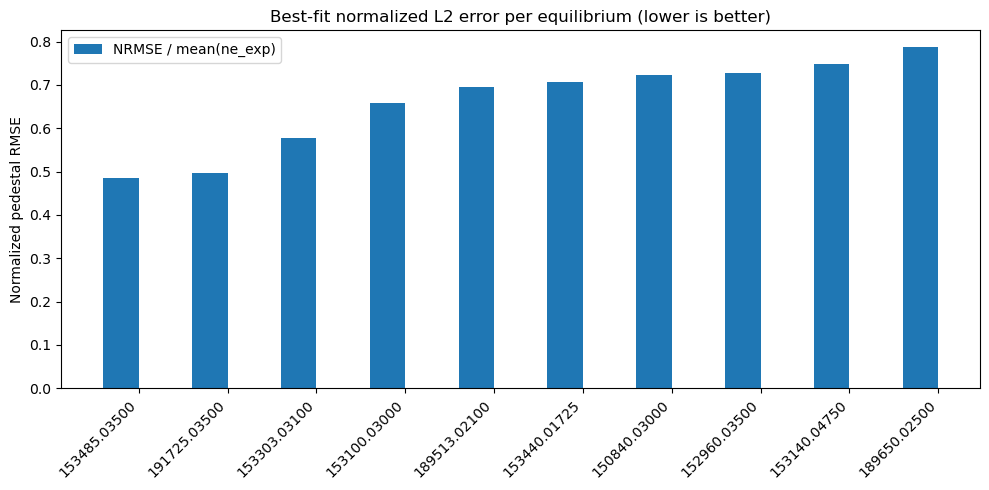

In [7]:
# Characterize L2 distance (pedestal RMSE) between each model run and the
# corresponding experimental p-file ne profile. For each equilibrium pick the
# best (lowest L2) parameter combination, then normalize the L2 across shots so
# they can be compared on the same scale.
#
# Normalizations reported (per equilibrium):
#   - rmse_abs   : raw RMSE on the pedestal grid, m^-3
#   - nrmse_mean : rmse_abs / mean(ne_pfile_ped)            -> relative error
#   - nrmse_peak : rmse_abs / max(ne_pfile_ped)             -> error vs. peak
#   - nrmse_rng  : rmse_abs / (max - min)(ne_pfile_ped)     -> error vs. pedestal step
# We use nrmse_mean as the primary cross-shot metric (unitless, intuitive).

import re
from scipy.interpolate import interp1d

# Same pedestal psi_N grid as scan_free_parameters.ipynb (psi_N_inner_boundary = 0.85).
psi_ped = np.linspace(0.85, 1.0, 200)

# Helper: read ne(psi_N) from a p-file (mirrors scan_free_parameters cell 7).
def read_pfile_ne(path):
    psi_arr, ne_arr = [], []
    in_ne_block = False
    with open(path) as f:
        for line in f:
            if '3 N Z A' in line:
                break
            if line.startswith('201'):
                in_ne_block = 'ne(10^20/m^3)' in line
                continue
            if in_ne_block:
                psi, val, _ = line.split()
                psi_arr.append(float(psi))
                ne_arr.append(float(val))
    return np.array(psi_arr), np.array(ne_arr) * 1e20  # m^-3


def best_l2_for_equilibrium(mhd_fp, kprof_fp, eq_dir, psi_ped):
    """Return (best_record, all_records) for one equilibrium."""

    # Reference model instance: only needed to build psi_N -> x mapping for this
    # equilibrium. Parameter values are arbitrary; we just need the geometry.
    ref = saarelma_connor(
        P_tot_e=P_tot_e,
        alpha_crit=alpha_crits[0],
        C_KBM=C_KBMs[0],
        De_chie_etg=De_chie_etgs[0],
        nFC_x0=nFC_x0s[0],
        mhd_fp=mhd_fp,
        kprof_fp=kprof_fp,
        verbose=False,
    )
    psi_to_x = interp1d(
        ref.psi_N_pres,
        ref.r_psi - ref.r_psi[-1],
        kind='linear', bounds_error=False, fill_value='extrapolate',
    )
    x_ped = psi_to_x(psi_ped)

    # Experimental ne on the pedestal psi grid.
    psi_pfile, ne_pfile = read_pfile_ne(kprof_fp)
    ne_pfile_ped = interp1d(
        psi_pfile, ne_pfile, kind='linear',
        bounds_error=False, fill_value='extrapolate',
    )(psi_ped)

    # Normalization scales derived from the experimental pedestal profile.
    ne_mean = float(np.mean(ne_pfile_ped))
    ne_peak = float(np.max(ne_pfile_ped))
    ne_rng = float(np.max(ne_pfile_ped) - np.min(ne_pfile_ped))

    pattern = re.compile(r"_([a-zA-Z])([\d.eE+-]+)")
    records = []
    for npy_path in eq_dir.glob('ne_*.npy'):
        pairs = pattern.findall(npy_path.stem)
        params = {letter: float(num) for letter, num in pairs}
        sol = np.load(npy_path, allow_pickle=True).item()
        ne_pred_ped = interp1d(
            sol.x, sol.y[0], kind='linear',
            bounds_error=False, fill_value='extrapolate',
        )(x_ped)
        # Drop NaN/inf points (degenerate solves) from the comparison.
        good = np.isfinite(ne_pred_ped) & np.isfinite(ne_pfile_ped)
        if not np.any(good):
            continue
        rmse_abs = float(np.sqrt(np.mean((ne_pred_ped[good] - ne_pfile_ped[good]) ** 2)))
        records.append({
            'alpha_crit':  params.get('a'),
            'C_KBM':       params.get('C'),
            'De_chie_etg': params.get('D'),
            'nFC_x0':      params.get('n'),
            'psi_inner':   params.get('b'),  # explicit psi_N_inner_boundary
            'rmse_abs':    rmse_abs,
            'nrmse_mean':  rmse_abs / ne_mean if ne_mean > 0 else np.nan,
            'nrmse_peak':  rmse_abs / ne_peak if ne_peak > 0 else np.nan,
            'nrmse_rng':   rmse_abs / ne_rng if ne_rng > 0 else np.nan,
            'ne_pred_ped': ne_pred_ped,
        })

    if not records:
        return None, [], {
            'x_ped': x_ped,
            'ne_pfile_ped': ne_pfile_ped,
            'ne_mean': ne_mean,
            'ne_peak': ne_peak,
            'ne_rng': ne_rng,
        }

    records.sort(key=lambda r: r['rmse_abs'])
    return records[0], records, {
        'x_ped': x_ped,
        'ne_pfile_ped': ne_pfile_ped,
        'ne_mean': ne_mean,
        'ne_peak': ne_peak,
        'ne_rng': ne_rng,
    }


# Walk every equilibrium that has successful runs on disk and find its best fit.
best_per_equilibrium = []
all_records_per_equilibrium = {}
context_per_equilibrium = {}

for mhd_fp, kprof_fp in equilibria:
    eq_tag = Path(mhd_fp).name[1:]
    eq_dir = scan_success_dir / eq_tag
    if not eq_dir.exists() or not any(eq_dir.glob('ne_*.npy')):
        print(f"[skip] No successful runs found for equilibrium {eq_tag}")
        continue

    best, all_records, ctx = best_l2_for_equilibrium(mhd_fp, kprof_fp, eq_dir, psi_ped)
    if best is None:
        print(f"[skip] All runs degenerate for equilibrium {eq_tag}")
        continue

    best['equilibrium'] = eq_tag
    best['n_runs'] = len(all_records)
    best['ne_peak_exp'] = ctx['ne_peak']
    best['ne_mean_exp'] = ctx['ne_mean']
    best_per_equilibrium.append(best)
    all_records_per_equilibrium[eq_tag] = all_records
    context_per_equilibrium[eq_tag] = ctx

# Rank equilibria by the primary cross-shot metric (nrmse_mean).
best_per_equilibrium.sort(key=lambda r: r['nrmse_mean'])

header = (f"{'rank':>4}  {'equilibrium':>14}  {'n_runs':>6}  "
          f"{'alpha_crit':>10}  {'C_KBM':>8}  {'De_chie_etg':>11}  {'nFC_x0':>12}  {'psi_inner':>10}  "
          f"{'rmse_abs (m^-3)':>16}  {'nrmse_mean':>10}  {'nrmse_peak':>10}  {'nrmse_rng':>10}")
print(header)
print('-' * len(header))
for rank, r in enumerate(best_per_equilibrium, start=1):
    psi_str = f"{r['psi_inner']:.4f}" if r['psi_inner'] is not None else "n/a"
    print(f"{rank:>4}  {r['equilibrium']:>14}  {r['n_runs']:>6d}  "
          f"{r['alpha_crit']:>10.3g}  {r['C_KBM']:>8.3g}  "
          f"{r['De_chie_etg']:>11.3g}  {r['nFC_x0']:>12.3g}  {psi_str:>10}  "
          f"{r['rmse_abs']:>16.3e}  {r['nrmse_mean']:>10.3e}  "
          f"{r['nrmse_peak']:>10.3e}  {r['nrmse_rng']:>10.3e}")

# Bar chart: normalized best-fit error per equilibrium for cross-shot comparison.
if best_per_equilibrium:
    labels = [r['equilibrium'] for r in best_per_equilibrium]
    nrmse_mean = [r['nrmse_mean'] for r in best_per_equilibrium]
    nrmse_peak = [r['nrmse_peak'] for r in best_per_equilibrium]

    x = np.arange(len(labels))
    width = 0.4

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(x - width / 2, nrmse_mean, width, label='NRMSE / mean(ne_exp)')
    # ax.bar(x + width / 2, nrmse_peak, width, label='NRMSE / peak(ne_exp)')
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.set_ylabel('Normalized pedestal RMSE')
    ax.set_title('Best-fit normalized L2 error per equilibrium (lower is better)')
    ax.legend()
    plt.tight_layout()
    plt.show()